In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import scipy.stats as stats

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [16]:
df = pd.read_csv('concrete_data.csv')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [18]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [24]:
df.isna().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Strength,0


In [25]:
X = df.drop('Strength', axis=1)
y = df['Strength']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/tmp/ipython-input-27-1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


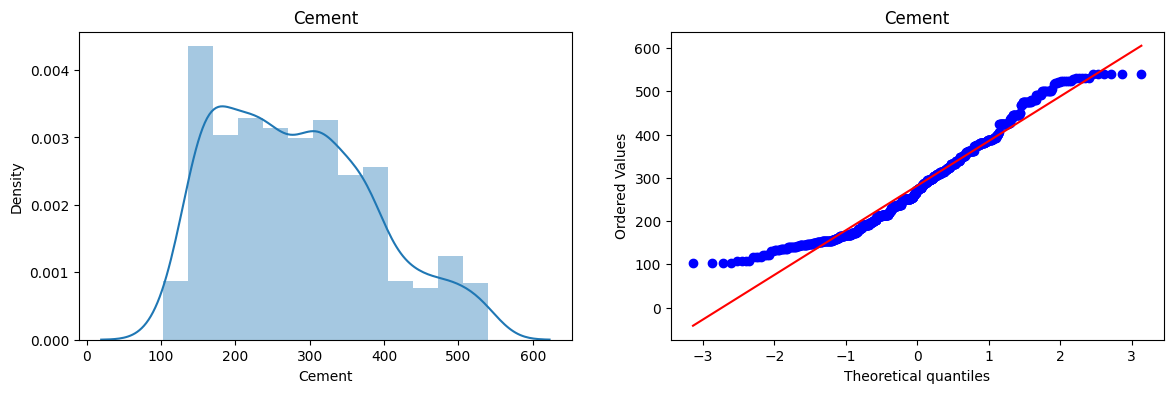

/tmp/ipython-input-27-1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


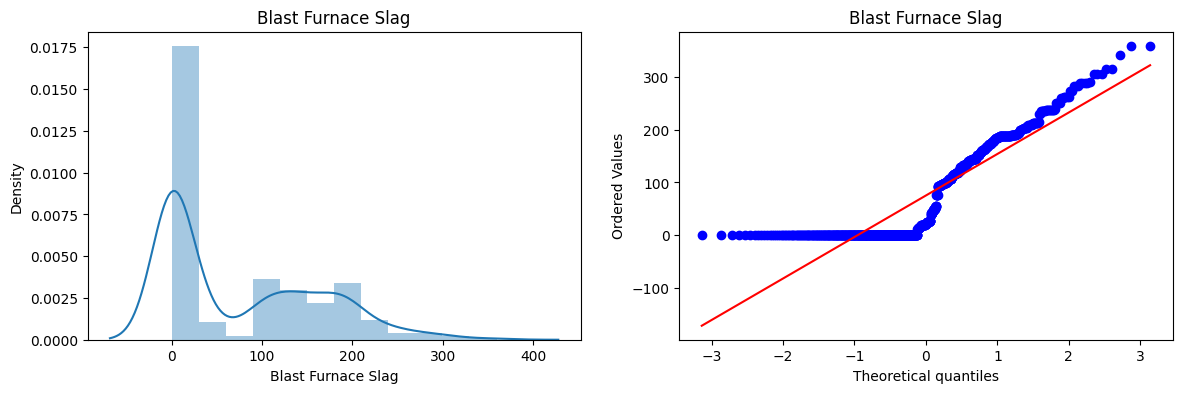

/tmp/ipython-input-27-1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


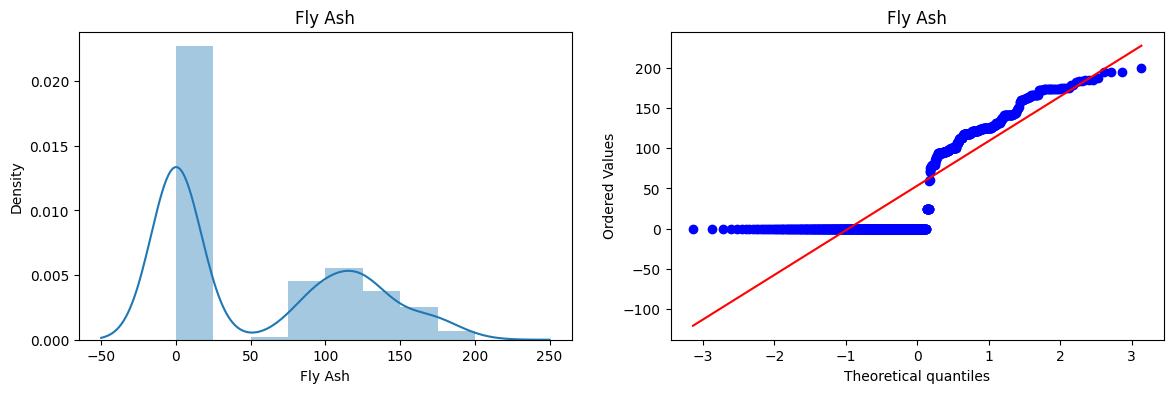

/tmp/ipython-input-27-1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


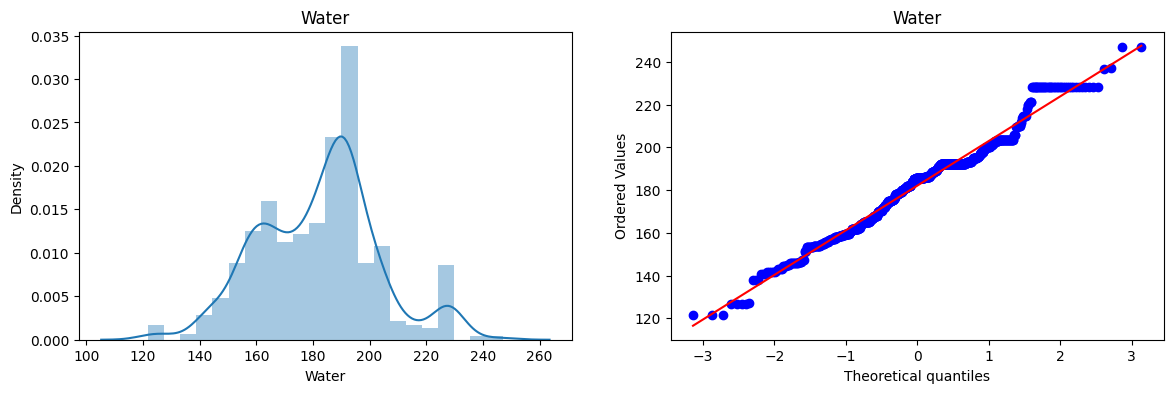

/tmp/ipython-input-27-1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


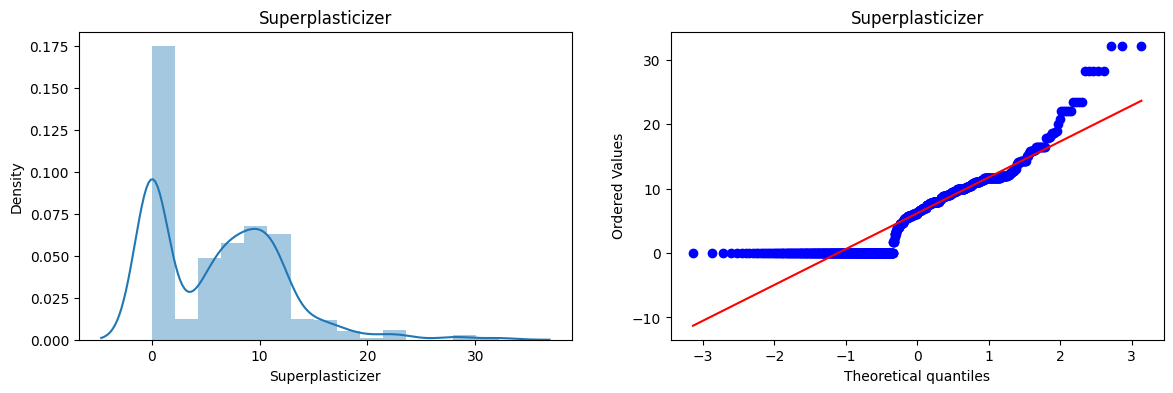

/tmp/ipython-input-27-1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


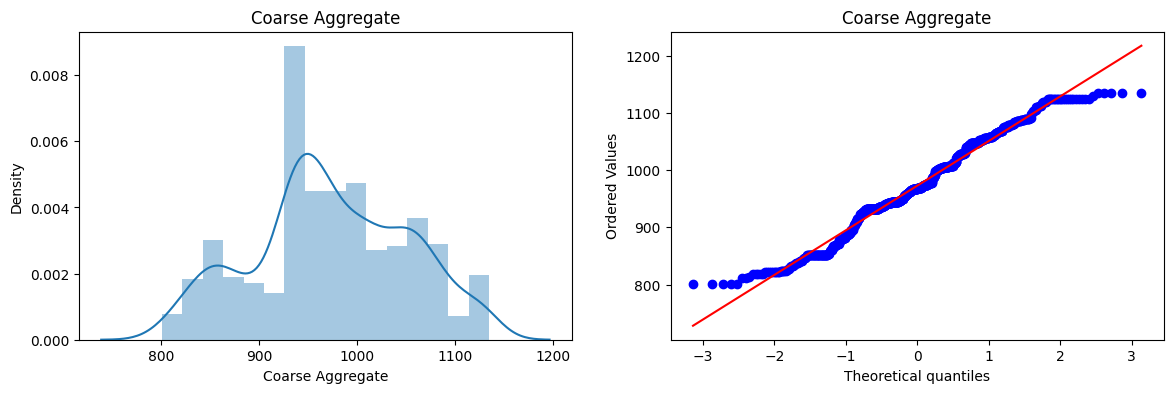

/tmp/ipython-input-27-1268627929.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col])


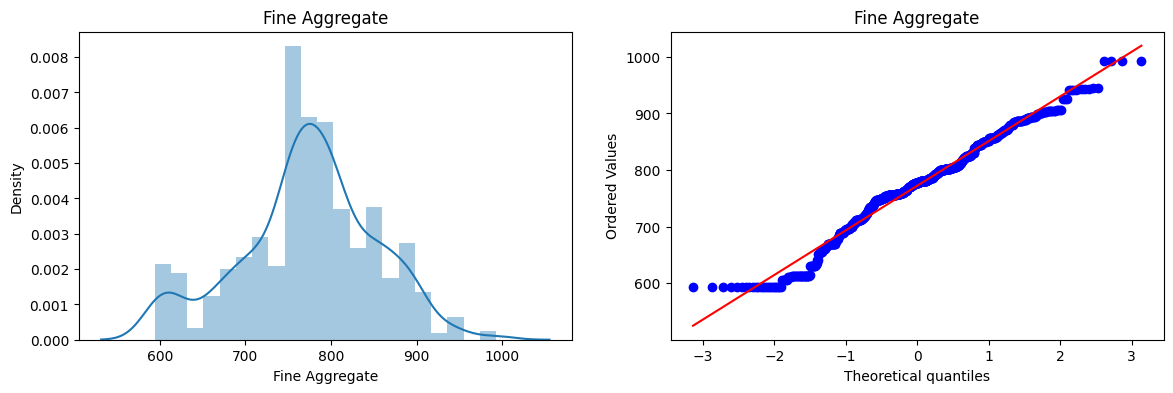

In [27]:
# Plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.distplot(X_train[col])
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [28]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

Since this is a regression problem, we should use regression models. Let's use `LinearRegression` and `DecisionTreeRegressor`.

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize regression models
reg1 = LinearRegression()
reg2 = DecisionTreeRegressor()

# Fit the models
reg1.fit(X_train, y_train)
reg2.fit(X_train, y_train)

# Make predictions
y_pred_reg1 = reg1.predict(X_test)
y_pred_reg2 = reg2.predict(X_test)

# Evaluate the models using regression metrics
print('Linear Regression Mean Squared Error:', mean_squared_error(y_test, y_pred_reg1))
print('Linear Regression R-squared:', r2_score(y_test, y_pred_reg1))
print('Decision Tree Regression Mean Squared Error:', mean_squared_error(y_test, y_pred_reg2))
print('Decision Tree Regression R-squared:', r2_score(y_test, y_pred_reg2))

Linear Regression Mean Squared Error: 149.69331129551716
Linear Regression R-squared: 0.3674242293277008
Decision Tree Regression Mean Squared Error: 165.69807389247367
Decision Tree Regression R-squared: 0.2997911136822715


In [32]:
trf = FunctionTransformer(func=np.log1p)

In [33]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

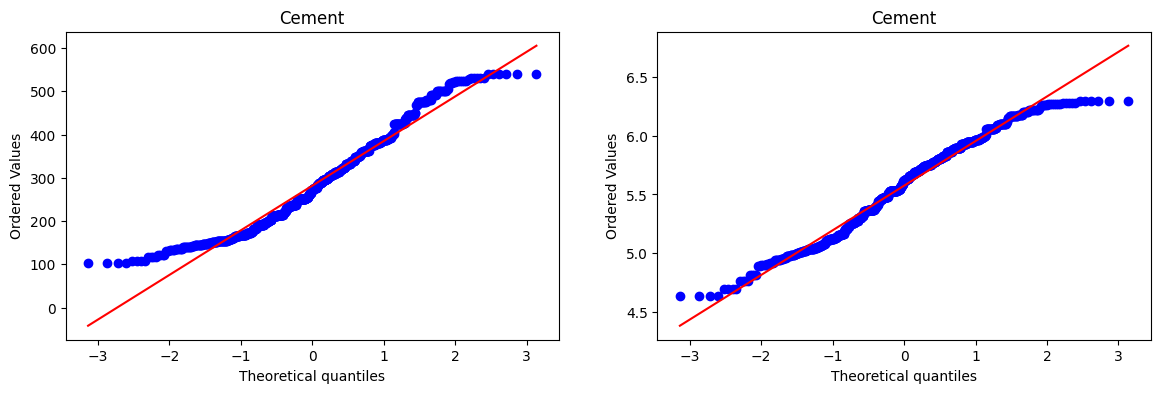

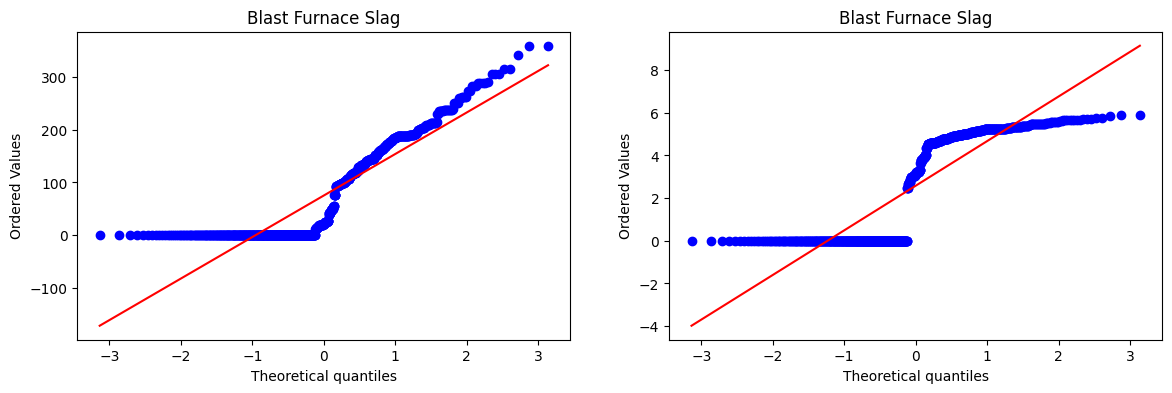

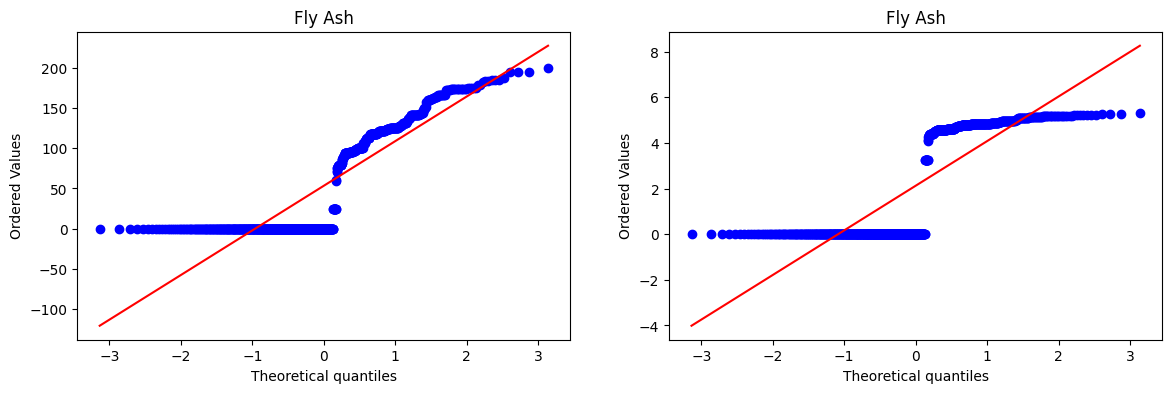

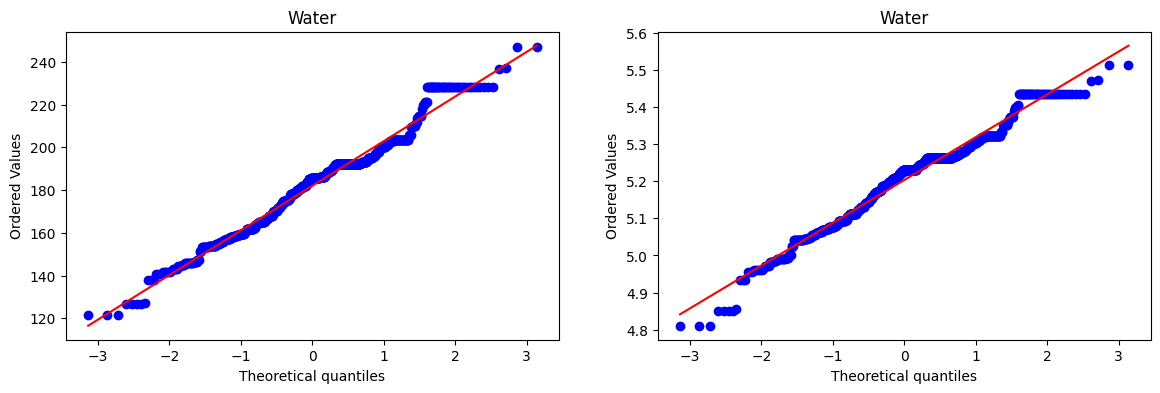

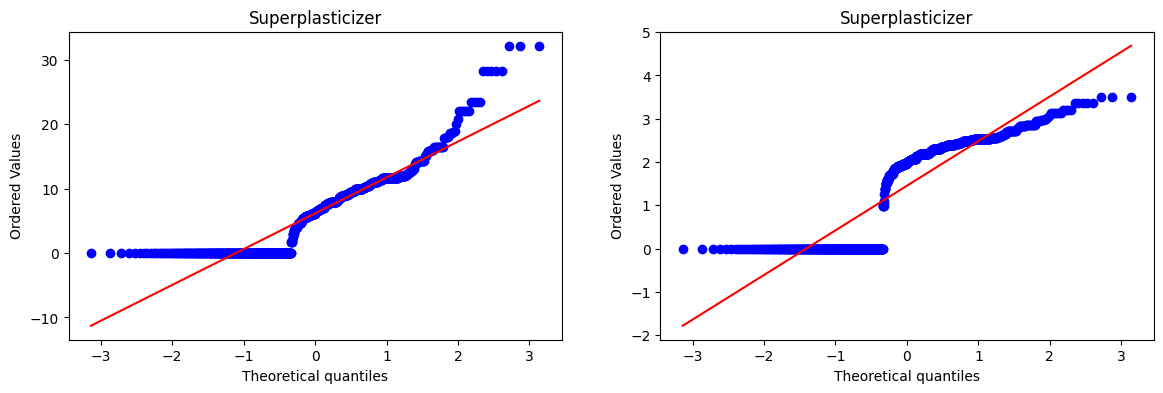

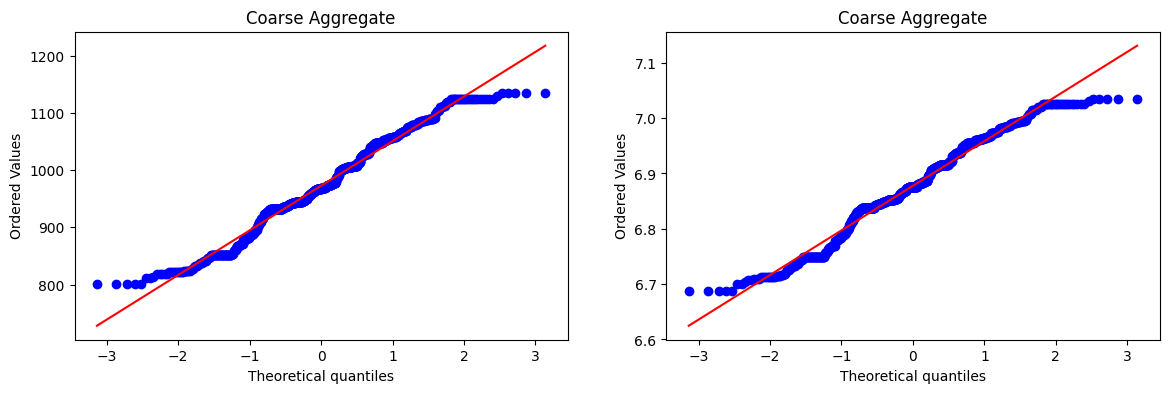

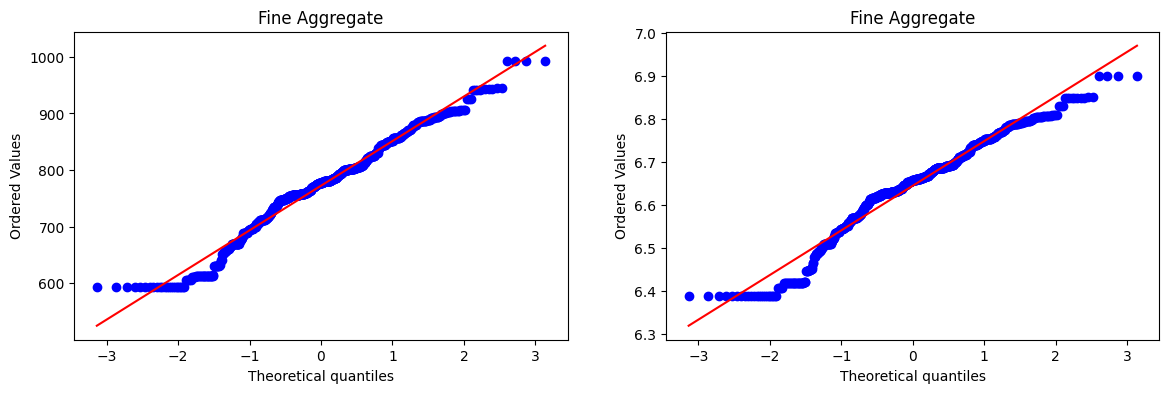

In [34]:
# Plotting the distplots without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(X_train[col], dist="norm",plot=plt)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train_transformed[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [35]:
reg = LinearRegression()
reg2 = DecisionTreeRegressor()

reg.fit(X_train_transformed,y_train)
reg2.fit(X_train_transformed,y_train)

y_pred = reg.predict(X_test_transformed)
y_pred1 = reg2.predict(X_test_transformed)

print("Linear Regression with transformed data:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))
print("-----------------------")
print("Decision Tree Regression with transformed data:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred1))
print("R-squared:", r2_score(y_test, y_pred1))

Linear Regression with transformed data:
Mean Squared Error: 149.84159420592442
R-squared: 0.3667976136458334
-----------------------
Decision Tree Regression with transformed data:
Mean Squared Error: 166.26839107779503
R-squared: 0.29738106055491353


In [36]:
X_transformed = trf.fit_transform(X)

reg = LinearRegression()
reg2 = DecisionTreeRegressor()

print("Linear Regression (Cross-validation R2):", np.mean(cross_val_score(reg, X_transformed, y, scoring='r2', cv=10)))
print("Decision Tree Regression (Cross-validation R2):", np.mean(cross_val_score(reg2, X_transformed, y, scoring='r2', cv=10)))

Linear Regression (Cross-validation R2): 0.03797011477191764
Decision Tree Regression (Cross-validation R2): -0.3581882632243172
